# Solutions : Out-of-Sample Testing — Tests hors-échantillon

> **L’Eurêka final :** une stratégie n’est pas validée parce qu’elle gagne sur le passé optimisé.  
> Elle commence à devenir crédible lorsqu’elle survit à des données qu’elle n’a jamais vues.

Dans ce notebook, on transforme l’idée EBTA en expérience Python.

L’objectif est simple :

- comprendre pourquoi le **backtest In-Sample** peut mentir ;
- comprendre pourquoi le **Out-of-Sample** est plus honnête ;
- simuler le **data-mining bias** ;
- construire un exemple simple de **Walk-Forward Testing** ;
- relier tout cela à une démarche de trader systématique.

## 1. Intuition fondamentale

Dans une recherche de stratégie, il y a deux mondes.

| Zone | Rôle | Risque principal |
|---|---:|---|
| **In-Sample** | Laboratoire de recherche | Optimisation excessive |
| **Out-of-Sample** | Examen final | Doit rester vierge |
| **Walk-Forward** | Série d’examens successifs | Plus réaliste mais plus exigeant |

Le **In-Sample** est utile pour chercher une règle.

Mais il ne suffit pas pour valider une règle.

Pourquoi ?

Parce que lorsque tu testes beaucoup de règles, tu finis presque toujours par trouver quelque chose qui marche sur le passé.

Même si le résultat est dû au hasard.

C’est exactement le piège du **data-mining bias**.

## 2. Modèle mental EBTA

On peut représenter la performance observée ainsi :

$$
P_{\text{obs}} = P_{\text{réel}} + H
$$

où :

- $P_{\text{obs}}$ est la performance observée dans le **backtest** ;
- $P_{\text{réel}}$ est le vrai pouvoir prédictif de la règle ;
- $H$ est la composante de **hasard**.

Quand tu mines beaucoup de règles, tu ne sélectionnes pas seulement la meilleure règle.

Tu sélectionnes aussi celle qui a reçu le plus de chance favorable dans l’échantillon.

Donc :

$$
P_{\text{IS sélectionné}} > P_{\text{réel attendu}}
$$

Le **Out-of-Sample** sert à casser cette illusion.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

def annualized_return(monthly_returns):
    """
    Calcule un rendement annualisé simple à partir de rendements mensuels.
    """
    return (1 + monthly_returns.mean()) ** 12 - 1

def sharpe_ratio(returns, periods_per_year=12):
    """
    Sharpe simplifié sans taux sans risque.
    """
    vol = returns.std(ddof=1)
    if vol == 0:
        return np.nan
    return np.sqrt(periods_per_year) * returns.mean() / vol

## 3. Expérience 1 — Le piège du meilleur backtest

On va créer un univers de règles sans aucun talent réel.

Toutes les règles ont une espérance vraie proche de zéro.

Mais on va en tester beaucoup.

Puis on va sélectionner celle qui a la meilleure performance **In-Sample**.

Question :

> Que se passe-t-il lorsque le trader choisit la meilleure règle sur le passé, puis la teste sur des données nouvelles ?

In [57]:
n_rules = 500
n_is = 60      # 60 mois In-Sample
n_oos = 24     # 24 mois Out-of-Sample

true_monthly_edge = 0
monthly_vol = 0.05

# Chaque ligne = une règle
# Chaque colonne = un mois de rendement
is_returns = np.random.normal(
    loc=true_monthly_edge,
    scale=monthly_vol,
    size=(n_rules, n_is)
)

oos_returns = np.random.normal(
    loc=true_monthly_edge,
    scale=monthly_vol,
    size=(n_rules, n_oos)
)

is_perf = np.array([annualized_return(r) for r in is_returns])
oos_perf = np.array([annualized_return(r) for r in oos_returns])

best_rule_idx = np.argmax(is_perf)

result = pd.DataFrame({
    "metric": [
        "Nombre de règles testées",
        "Meilleure règle sélectionnée",
        "Performance annualisée IS de la meilleure règle",
        "Performance annualisée OOS de la même règle",
        "Moyenne OOS de toutes les règles"
    ],
    "value": [
        n_rules,
        best_rule_idx,
        f"{is_perf[best_rule_idx]:.2%}",
        f"{oos_perf[best_rule_idx]:.2%}",
        f"{oos_perf.mean():.2%}"
    ]
})

result

,metric,value
0,Nombre de règles testées,500
1,Meilleure règle sélectionnée,208
2,Performance annualisée IS de la meilleure règle,24.53%
3,Performance annualisée OOS de la même règle,-15.87%
4,Moyenne OOS de toutes les règles,1.05%


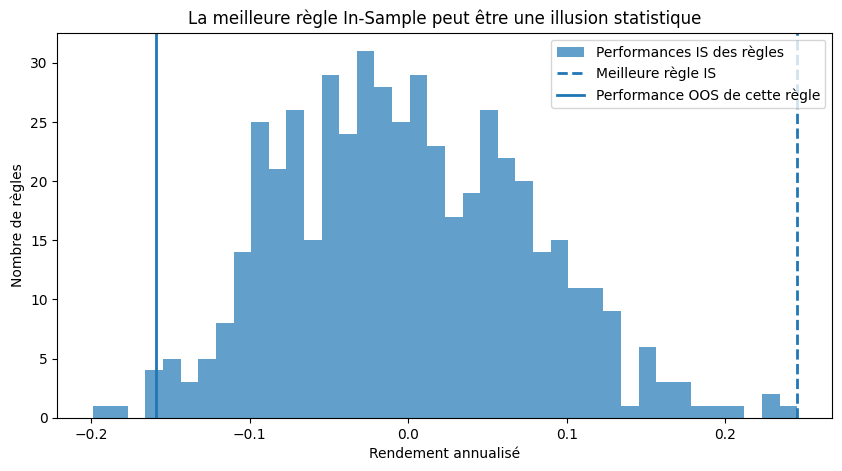

In [58]:
plt.figure(figsize=(10, 5))
plt.hist(is_perf, bins=40, alpha=0.7, label="Performances IS des règles")
plt.axvline(is_perf[best_rule_idx], linestyle="--", linewidth=2, label="Meilleure règle IS")
plt.axvline(oos_perf[best_rule_idx], linestyle="-", linewidth=2, label="Performance OOS de cette règle")
plt.title("La meilleure règle In-Sample peut être une illusion statistique")
plt.xlabel("Rendement annualisé")
plt.ylabel("Nombre de règles")
plt.legend()
plt.show()

### Lecture du graphique

La meilleure règle **In-Sample** peut afficher une performance spectaculaire.

Mais dans cette simulation, aucune règle n’a de vrai talent.

Donc la surperformance observée vient surtout de la chance.

Le test **Out-of-Sample** révèle que la règle sélectionnée revient vers une performance beaucoup plus ordinaire.

> **Idée clé :** le OOS ne rend pas une stratégie profitable.  
> Il révèle si le profit IS avait une chance raisonnable d’être réel.

## 4. Expérience 2 — Plus on teste de règles, plus le mirage grossit

Testons plusieurs tailles d’univers.

On va observer la performance moyenne de la meilleure règle sélectionnée **In-Sample**, puis sa performance **Out-of-Sample**.

In [59]:
def simulate_data_mining(n_rules, n_is=60, n_oos=24, n_sims=300, true_edge=0.0, vol=0.05):
    rows = []

    for sim in range(n_sims):
        is_r = np.random.normal(true_edge, vol, size=(n_rules, n_is))
        oos_r = np.random.normal(true_edge, vol, size=(n_rules, n_oos))

        is_perf = np.array([annualized_return(r) for r in is_r])
        oos_perf = np.array([annualized_return(r) for r in oos_r])

        best = np.argmax(is_perf)

        rows.append({
            "n_rules": n_rules,
            "best_is": is_perf[best],
            "same_rule_oos": oos_perf[best],
            "bias_gap": is_perf[best] - oos_perf[best]
        })

    return pd.DataFrame(rows)

universe_sizes = [5, 10, 30, 100, 300, 500, 1000]
all_sims = pd.concat(
    [simulate_data_mining(n) for n in universe_sizes],
    ignore_index=True
)

summary = (
    all_sims
    .groupby("n_rules")
    .agg(
        avg_best_is=("best_is", "mean"),
        avg_oos=("same_rule_oos", "mean"),
        avg_bias_gap=("bias_gap", "mean")
    )
    .reset_index()
)

summary.style.format({
    "avg_best_is": "{:.2%}",
    "avg_oos": "{:.2%}",
    "avg_bias_gap": "{:.2%}"
})

,n_rules,avg_best_is,avg_oos,avg_bias_gap
0,5,9.58%,1.01%,8.57%
1,10,13.24%,-0.26%,13.51%
2,30,17.64%,1.62%,16.02%
3,100,21.43%,0.36%,21.07%
4,300,24.97%,-0.49%,25.46%
5,500,26.19%,0.89%,25.30%
6,1000,28.21%,0.86%,27.35%


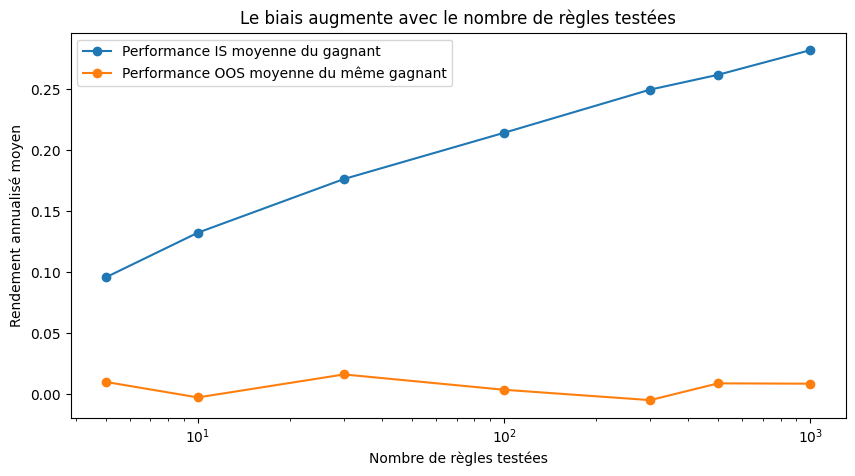

In [60]:
plt.figure(figsize=(10, 5))
plt.plot(summary["n_rules"], summary["avg_best_is"], marker="o", label="Performance IS moyenne du gagnant")
plt.plot(summary["n_rules"], summary["avg_oos"], marker="o", label="Performance OOS moyenne du même gagnant")
plt.xscale("log")
plt.title("Le biais augmente avec le nombre de règles testées")
plt.xlabel("Nombre de règles testées")
plt.ylabel("Rendement annualisé moyen")
plt.legend()
plt.show()

### Interprétation

Quand le nombre de règles testées augmente, la meilleure performance **IS** monte mécaniquement.

Mais la performance **OOS** ne suit pas.

C’est le cœur du biais de minage de données :

$$
\text{Biais de minage} =
P_{\text{IS sélectionné}} - P_{\text{OOS réel}}
$$

Plus tu cherches intensivement, plus tu dois être sévère dans la validation.

## 5. Split simple IS/OOS

Le split simple consiste à prendre :

- les premières observations pour la recherche ;
- les dernières observations pour le test final.

Exemple :

| Segment | Usage | Autorisé ? |
|---|---|---|
| 2015–2022 | Recherche et optimisation | Oui |
| 2023–2025 | Validation finale | Non, jusqu’au test final |

Le point crucial :

> Une fois que tu utilises le OOS pour modifier la stratégie, ce n’est plus un OOS.  
> Il devient un nouveau In-Sample déguisé.

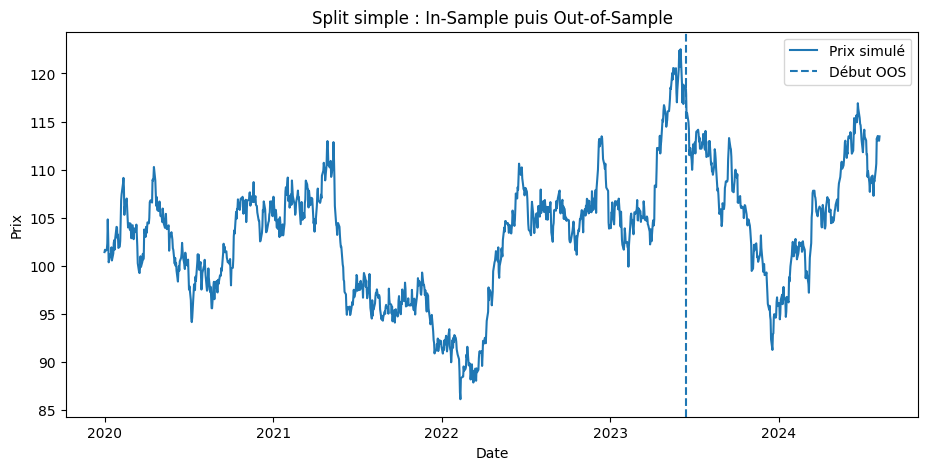

In [96]:
# Simulation d'une série de prix simple
np.random.seed(39)

n_days = 1200
dates = pd.date_range("2020-01-01", periods=n_days, freq="B")

daily_returns = np.random.normal(0.0002, 0.01, size=n_days)
price = 100 * (1 + pd.Series(daily_returns, index=dates)).cumprod()

data = pd.DataFrame({"close": price})
data["return"] = data["close"].pct_change().fillna(0)

split_ratio = 0.75
split_idx = int(len(data) * split_ratio)

is_data = data.iloc[:split_idx].copy()
oos_data = data.iloc[split_idx:].copy()

plt.figure(figsize=(11, 5))
plt.plot(data.index, data["close"], label="Prix simulé")
plt.axvline(data.index[split_idx], linestyle="--", label="Début OOS")
plt.title("Split simple : In-Sample puis Out-of-Sample")
plt.xlabel("Date")
plt.ylabel("Prix")
plt.legend()
plt.show()

## 6. Exemple de stratégie simple : moyenne mobile

On teste une stratégie volontairement simple :

- achat si le prix est au-dessus de sa moyenne mobile ;
- sortie ou cash si le prix est sous sa moyenne mobile.

On va optimiser la fenêtre de moyenne mobile sur le **In-Sample**.

Puis appliquer le meilleur paramètre sur le **Out-of-Sample**.

In [97]:
def moving_average_strategy(df, window):
    """
    Stratégie long/cash :
    - long si close > moyenne mobile
    - cash sinon
    """
    out = df.copy()
    out["ma"] = out["close"].rolling(window).mean()
    out["signal"] = (out["close"] > out["ma"]).astype(int)
    out["strategy_return"] = out["signal"].shift(1).fillna(0) * out["return"]
    return out

windows = list(range(5, 201, 5))

rows = []
for w in windows:
    test = moving_average_strategy(is_data, w)
    rows.append({
        "window": w,
        "is_return": annualized_return(test["strategy_return"]),
        "is_sharpe": sharpe_ratio(test["strategy_return"], periods_per_year=252)
    })

is_optimization = pd.DataFrame(rows)
best_window = int(is_optimization.loc[is_optimization["is_sharpe"].idxmax(), "window"])

best_window

195

In [98]:
# Test OOS avec le paramètre choisi uniquement sur IS
best_is = moving_average_strategy(is_data, best_window)
best_oos = moving_average_strategy(oos_data, best_window)

comparison = pd.DataFrame({
    "Segment": ["In-Sample", "Out-of-Sample"],
    "Window utilisée": [best_window, best_window],
    "Rendement annualisé": [
        annualized_return(best_is["strategy_return"]),
        annualized_return(best_oos["strategy_return"])
    ],
    "Sharpe": [
        sharpe_ratio(best_is["strategy_return"], periods_per_year=252),
        sharpe_ratio(best_oos["strategy_return"], periods_per_year=252)
    ]
})

comparison.style.format({
    "Rendement annualisé": "{:.2%}",
    "Sharpe": "{:.2f}"
})

,Segment,Window utilisée,Rendement annualisé,Sharpe
0,In-Sample,195,0.24%,0.45
1,Out-of-Sample,195,0.32%,0.85


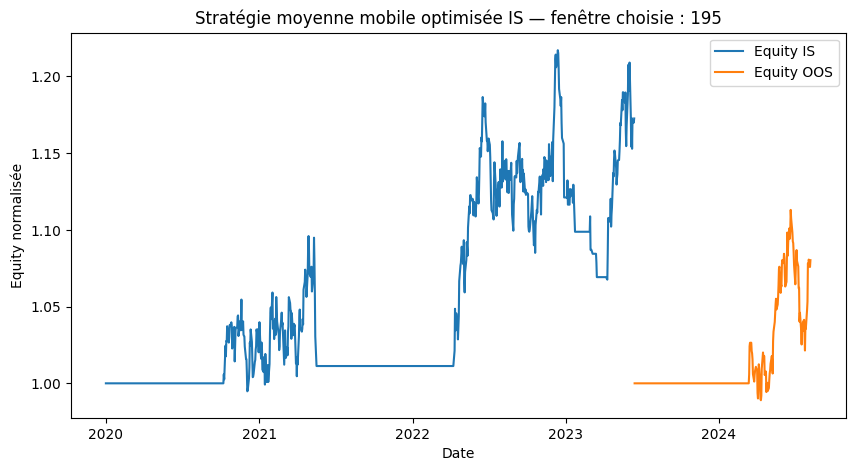

In [99]:
equity_is = (1 + best_is["strategy_return"]).cumprod()
equity_oos = (1 + best_oos["strategy_return"]).cumprod()

plt.figure(figsize=(10, 5))
plt.plot(equity_is.index, equity_is, label="Equity IS")
plt.plot(equity_oos.index, equity_oos, label="Equity OOS")
plt.title(f"Stratégie moyenne mobile optimisée IS — fenêtre choisie : {best_window}")
plt.xlabel("Date")
plt.ylabel("Equity normalisée")
plt.legend()
plt.show()

## 7. Le danger du OOS snooping

Une mauvaise pratique très courante :

1. optimiser en **IS** ;
2. tester en **OOS** ;
3. être déçu ;
4. modifier les paramètres ;
5. retester sur le même OOS ;
6. répéter jusqu’à obtenir un bon OOS.

Le problème :

$$
\text{OOS réutilisé plusieurs fois} \Rightarrow \text{nouveau biais de minage}
$$

À partir du moment où tu regardes le OOS pour prendre une décision de recherche, tu l’as contaminé.

> **Règle pratique :** le OOS sert à juger.  
> Il ne sert pas à entraîner.

## 8. Walk-Forward Testing

Le **Walk-Forward Testing** découpe le temps en plusieurs folds.

Chaque fold contient :

- une fenêtre d’entraînement ;
- une fenêtre de test ;
- puis la fenêtre avance.

Visuellement :

| Fold | Training | Testing |
|---:|---|---|
| 1 | Période 1 | Période 2 |
| 2 | Période 2 | Période 3 |
| 3 | Période 3 | Période 4 |

L’avantage est que l’on simule une situation plus réaliste :

> À chaque étape, le trader n’utilise que le passé disponible pour choisir sa règle, puis il teste sur le futur immédiat.

In [100]:
def walk_forward_test(df, train_size=500, test_size=100, windows=None):
    """
    Walk-forward simple :
    - optimise la fenêtre MA sur le segment train
    - applique la meilleure fenêtre sur le segment test
    """
    if windows is None:
        windows = list(range(5, 201, 5))

    folds = []
    all_test_parts = []

    start = 0
    fold_id = 1

    while start + train_size + test_size <= len(df):
        train = df.iloc[start:start + train_size].copy()
        test = df.iloc[start + train_size:start + train_size + test_size].copy()

        opt_rows = []
        for w in windows:
            train_bt = moving_average_strategy(train, w)
            opt_rows.append({
                "window": w,
                "train_sharpe": sharpe_ratio(train_bt["strategy_return"], periods_per_year=252),
                "train_return": annualized_return(train_bt["strategy_return"])
            })

        opt = pd.DataFrame(opt_rows).dropna()
        chosen_w = int(opt.loc[opt["train_sharpe"].idxmax(), "window"])

        test_bt = moving_average_strategy(test, chosen_w)
        test_bt["fold"] = fold_id
        test_bt["chosen_window"] = chosen_w

        folds.append({
            "fold": fold_id,
            "train_start": train.index[0],
            "train_end": train.index[-1],
            "test_start": test.index[0],
            "test_end": test.index[-1],
            "chosen_window": chosen_w,
            "train_best_sharpe": opt["train_sharpe"].max(),
            "test_sharpe": sharpe_ratio(test_bt["strategy_return"], periods_per_year=252),
            "test_return": annualized_return(test_bt["strategy_return"])
        })

        all_test_parts.append(test_bt)

        start += test_size
        fold_id += 1

    folds_df = pd.DataFrame(folds)
    wf_returns = pd.concat(all_test_parts).sort_index()

    return folds_df, wf_returns

folds_df, wf_returns = walk_forward_test(
    data,
    train_size=500,
    test_size=100,
    windows=windows
)

folds_df.style.format({
    "train_best_sharpe": "{:.2f}",
    "test_sharpe": "{:.2f}",
    "test_return": "{:.2%}"
})

,fold,train_start,train_end,test_start,test_end,chosen_window,train_best_sharpe,test_sharpe,test_return
0,1,2020-01-01 00:00:00,2021-11-30 00:00:00,2021-12-01 00:00:00,2022-04-19 00:00:00,195,0.11,nan,0.00%
1,2,2020-05-20 00:00:00,2022-04-19 00:00:00,2022-04-20 00:00:00,2022-09-06 00:00:00,175,0.08,nan,0.00%
2,3,2020-10-07 00:00:00,2022-09-06 00:00:00,2022-09-07 00:00:00,2023-01-24 00:00:00,165,0.88,nan,0.00%
3,4,2021-02-24 00:00:00,2023-01-24 00:00:00,2023-01-25 00:00:00,2023-06-13 00:00:00,190,0.46,nan,0.00%
4,5,2021-07-14 00:00:00,2023-06-13 00:00:00,2023-06-14 00:00:00,2023-10-31 00:00:00,190,0.69,nan,0.00%
5,6,2021-12-01 00:00:00,2023-10-31 00:00:00,2023-11-01 00:00:00,2024-03-19 00:00:00,75,0.28,1.45,0.56%
6,7,2022-04-20 00:00:00,2024-03-19 00:00:00,2024-03-20 00:00:00,2024-08-06 00:00:00,15,0.13,1.95,0.88%


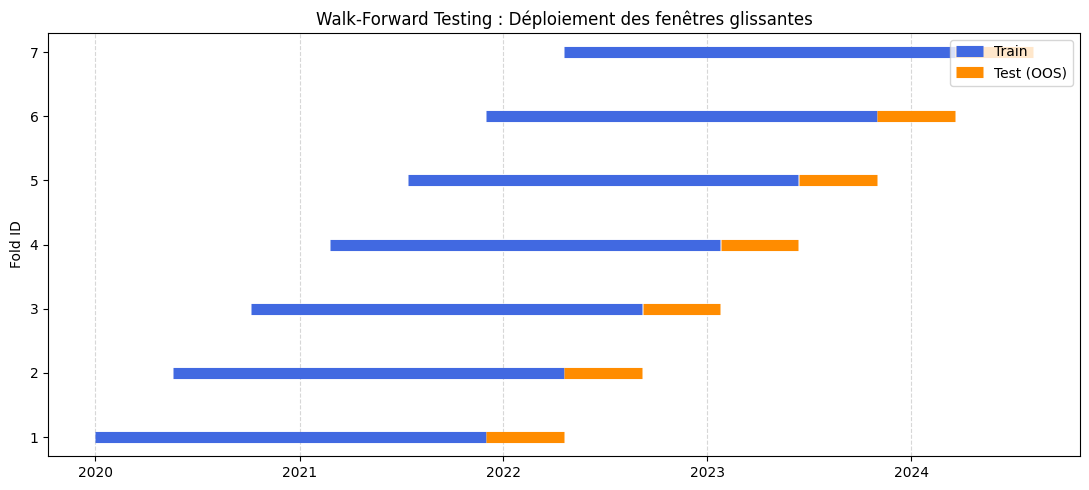

In [103]:
# Création de la figure (taille cohérente avec le reste du notebook)
fig, ax = plt.subplots(figsize=(11, 5))

# Affichage des fenêtres Train et Test pour chaque Fold
for idx, row in folds_df.iterrows():
    f_id = row['fold']
    
    # Segment d'entraînement (Train)
    ax.plot([row['train_start'], row['train_end']], [f_id, f_id], 
            color='royalblue', linewidth=8, solid_capstyle='butt', 
            label='Train' if idx == 0 else "")
    
    # Segment de test (Test - OOS)
    ax.plot([row['test_start'], row['test_end']], [f_id, f_id], 
            color='darkorange', linewidth=8, solid_capstyle='butt', 
            label='Test (OOS)' if idx == 0 else "")

ax.set_yticks(folds_df['fold'])
ax.set_ylabel("Fold ID")
ax.set_title("Walk-Forward Testing : Déploiement des fenêtres glissantes")
ax.legend(loc='upper right')
ax.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


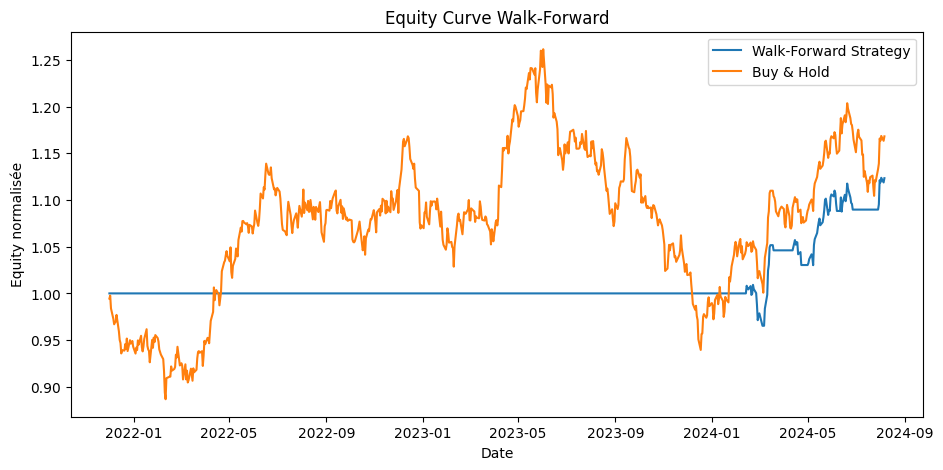

In [104]:
wf_equity = (1 + wf_returns["strategy_return"]).cumprod()
buy_hold_equity = (1 + data.loc[wf_equity.index, "return"]).cumprod()

plt.figure(figsize=(11, 5))
plt.plot(wf_equity.index, wf_equity, label="Walk-Forward Strategy")
plt.plot(buy_hold_equity.index, buy_hold_equity, label="Buy & Hold")
plt.title("Equity Curve Walk-Forward")
plt.xlabel("Date")
plt.ylabel("Equity normalisée")
plt.legend()
plt.show()

In [105]:
wf_summary = pd.DataFrame({
    "Metric": [
        "Nombre de folds",
        "Rendement annualisé Walk-Forward",
        "Sharpe Walk-Forward",
        "Fenêtre moyenne sélectionnée",
        "Fenêtre min sélectionnée",
        "Fenêtre max sélectionnée"
    ],
    "Value": [
        len(folds_df),
        f"{annualized_return(wf_returns['strategy_return']):.2%}",
        f"{sharpe_ratio(wf_returns['strategy_return'], periods_per_year=252):.2f}",
        f"{folds_df['chosen_window'].mean():.1f}",
        int(folds_df["chosen_window"].min()),
        int(folds_df["chosen_window"].max())
    ]
})

wf_summary

,Metric,Value
0,Nombre de folds,7
1,Rendement annualisé Walk-Forward,0.20%
2,Sharpe Walk-Forward,0.92
3,Fenêtre moyenne sélectionnée,143.6
4,Fenêtre min sélectionnée,15
5,Fenêtre max sélectionnée,195


## 9. Comment lire un Walk-Forward comme un quant

Un bon Walk-Forward ne se juge pas seulement avec une equity curve.

Il faut regarder :

| Question | Interprétation |
|---|---|
| Les performances OOS sont-elles positives en moyenne ? | La règle survit-elle hors laboratoire ? |
| Les folds sont-ils stables ? | La règle dépend-elle d’une seule période chanceuse ? |
| Les paramètres choisis changent-ils brutalement ? | Risque d’instabilité du modèle |
| La performance chute-t-elle fortement entre train et test ? | Signe de sur-optimisation |
| Le résultat reste-t-il viable après frais ? | Réalité économique |

Le Walk-Forward n’élimine pas tous les biais.

Mais il rend le protocole beaucoup plus proche d’une vraie exploitation en temps réel.

## 10. Check-list EBTA pour un vrai protocole OOS

Avant de lancer un projet de backtest sérieux, tu peux utiliser cette check-list.

| Étape | Question | Validation |
|---:|---|---|
| 1 | Ai-je isolé le OOS avant toute optimisation ? | Oui / Non |
| 2 | Ai-je limité le nombre de décisions après avoir vu le OOS ? | Oui / Non |
| 3 | Ai-je documenté les paramètres avant le test final ? | Oui / Non |
| 4 | Ai-je comparé IS vs OOS sans retoucher la règle ? | Oui / Non |
| 5 | Ai-je testé la robustesse sur plusieurs folds ? | Oui / Non |
| 6 | Ai-je inclus frais, slippage, spread ? | Oui / Non |
| 7 | Ai-je une raison économique derrière la stratégie ? | Oui / Non |

> **Conclusion pratique :** une stratégie qui marche seulement en IS n’est pas une stratégie.  
> C’est une hypothèse non validée.

## 11. Résumé final

Le **Out-of-Sample Testing** est une défense contre l’auto-déception statistique.

Il répond à une question simple :

> La règle gagne-t-elle encore lorsqu’elle ne peut plus tricher avec le passé ?

À retenir :

- Le **In-Sample** sert à chercher.
- Le **Out-of-Sample** sert à juger.
- Le **Walk-Forward** simule une recherche adaptative dans le temps.
- Réutiliser le OOS pour ajuster la règle le contamine.
- La performance OOS est généralement plus proche de la réalité future que la performance IS optimisée.

$$
\text{Validation sérieuse} =
\text{Recherche IS} + \text{Test OOS vierge} + \text{Robustesse Walk-Forward}
$$

> **L’Eurêka final :** le but n’est pas de trouver une stratégie qui a parfaitement expliqué le passé.  
> Le but est de trouver une règle assez robuste pour survivre à l’inconnu.

## Annexe — Texte source fourni

### **SOLUTIONS : OUT-OF-SAMPLE TESTING (TESTS HORS-ÉCHANTILLON)**

Cette section détaille l'une des méthodes fondamentales pour contrer le biais de minage de données : l'utilisation de données "vierges" pour valider une stratégie.

---

#### **Idées clés :**
*   **Estimation non biaisée :** La performance d'une règle sur des données hors-échantillon fournit une estimation honnête de sa rentabilité future, contrairement au backtest optimisé.
*   **Préservation de la virginité :** Les données hors-échantillon ne doivent jamais être utilisées pour sélectionner ou ajuster la règle, sous peine d'être "souillées".
*   **Segmentation des données :** Il existe plusieurs schémas pour diviser l'historique (split simple, damier, ou fenêtres glissantes).
*   **Walk-Forward Testing :** Une approche dynamique où la règle "apprend" sur un segment et est testée sur le suivant avant que la fenêtre ne se déplace.

---

#### **Référence :**
*Out-of-Sample Testing*, Chapitre 6, pages 321 à 324.

---

#### **Citation Directe :**
« Out-of-sample testing is based on the valid notion that the performance of a data-mined rule, in out-of-sample data, provides an unbiased estimate of the rule’s future performance. » (Page 321).

---

#### **Vision Macro :**
L'enjeu est la lutte contre l'auto-déception. David Aronson explique que le minage de données (chercher le meilleur réglage) est un processus qui "aspire" naturellement le hasard présent dans les données passées. Le test hors-échantillon agit comme un juge de paix indépendant : il vérifie si le profit détecté par l'ordinateur provient d'un motif réel (pouvoir prédictif) ou d'une simple coïncidence statistique qui ne se répétera pas.

---

#### **Vision Micro :**
Le mécanisme repose sur la séparation stricte de l'historique en deux segments :

1.  **In-Sample (IS) :** C'est le laboratoire. Le trader teste des milliers de règles et de paramètres sur ces données pour extraire le "gagnant".
2.  **Out-of-Sample (OOS) :** C'est l'examen final. On applique la règle gagnante sur ces données pour la première fois.
3.  **Méthodes de segmentation (Figure 6.56) :**
    *   **Split simple (A) :** Les premières années pour le minage, les dernières pour le test.
    *   **Damier (B/C) :** On alterne des blocs de données IS et OOS sur toute la période pour capter différents régimes de marché.
4.  **Walk-Forward Testing (Figure 6.57) :** On définit une "fold" (pli) composée d'un segment d'entraînement (Training) et d'un segment de test (Testing). Une fois le test fini, on avance toute la fenêtre dans le temps pour recommencer l'opération. Cela permet de produire plusieurs estimations indépendantes de la performance future.

---

#### **Résumé Simplifié :**
Imaginez que vous passiez un examen de mathématiques. Si vous avez déjà les réponses (In-Sample), votre note sera excellente mais elle ne prouve pas que vous êtes bon en maths. Pour savoir ce que vous valez vraiment, on vous donne un nouvel examen avec des chiffres différents (Out-of-Sample). Si vous réussissez aussi cet examen, alors votre talent est réel.

---

#### **Actions Concrètes :**
*   **Réserver 20 à 30 % des données :** Avant de commencer toute recherche, isolez une partie de votre historique et ne la regardez jamais avant d'avoir fini votre stratégie.
*   **Éviter le "snooping" hors-échantillon :** Si une règle échoue en OOS, ne revenez pas en arrière pour modifier vos paramètres et retester sur le même échantillon, car l'OOS n'est plus "vierge" et le biais de minage y pénètre.
*   **Utiliser le Walk-Forward :** Privilégiez cette méthode si vous pensez que les dynamiques de marché changent avec le temps, car elle simule une adaptation continue de la stratégie.
*   **Analyser la chute de performance :** Attendez-vous à ce que le profit OOS soit inférieur au profit IS. Si la chute est trop brutale, rejetez la règle.

---

#### **À retenir absolument :**
*   Le test hors-échantillon est le **seul moyen d'obtenir une estimation honnête** du futur.
*   Une donnée utilisée une fois pour un test n'est **plus jamais vierge**.
*   Le minage de données intensif nécessite des **segments de données totalement isolés**.
*   Le **Walk-Forward** est la méthode la plus robuste pour les marchés non stationnaires.
*   La performance IS est un mirage ; la performance OOS est la **réalité économique**.

J'ai terminé l'analyse de la section sur les tests hors-échantillon selon le protocole EBTA.